In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../upi_dataset/upi fraud dataset.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

There are 11 columns and 6362620 records

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

There are no nan values or null values in dataset

LET see how many payments type we have

In [6]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

This are the types of payments 'PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],

In [7]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

0 specifies normal transaction were as 1 specifies fraud

In [29]:
df[(df['type']=='PAYMENT') | (df['type']=='TRANSFER')]['isFraud'].value_counts()

isFraud
0    2680307
1       4097
Name: count, dtype: int64

In [4]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.duplicated().sum()

np.int64(0)

fEATURE ENGINEERIN



. EXTRACTING THE HOUR FROM STEP 



. FLAG TRANSACTION OCCURING BETWEEN MIDNIGHT AND 6 AM

In [7]:
df['step'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [8]:
df['hour']=df['step']%24
df['midnight']=df['hour'].apply(lambda x: 1 if x<6 else 0)

In [9]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,midnight
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,23,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,23,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,23,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,23,0


##comparing the ratios of bankbalance before and after transaction

. sender balance =old balance- new balance

. receiver balance=old balance - new balance

In [10]:
df['sender_balance_diff']=df['oldbalanceOrg']-df['newbalanceOrig']
df['receiver_balance_diff']=df['oldbalanceDest']-df['newbalanceDest']

In [11]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,midnight,sender_balance_diff,receiver_balance_diff
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,1,1,9839.64,0.00
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1,1,1864.28,0.00
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,1,1,181.00,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,1,1,181.00,21182.00
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,1,1,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,23,0,339682.13,-339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,23,0,6311409.28,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,23,0,6311409.28,-6311409.27
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,23,0,850002.52,0.00


In [21]:
df['midnight'][df['isFraud']==1].value_counts()

midnight
0    6217
1    1996
Name: count, dtype: int64

In [ ]:
list=df['hour'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23,  0])

In [34]:
df['hour'].apply(lambda x: x < 6) & (df['isFraud'] == 1).value_counts()

C:\Users\zaid\AppData\Local\Temp\ipykernel_8344\379514732.py:1: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  df['hour'].apply(lambda x: x < 6) & (df['isFraud'] == 1).value_counts()


0           True
1           True
2          False
3          False
4          False
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Length: 6362620, dtype: bool

In [22]:
df[df['amount']>1000000]['isFraud'].value_counts()

isFraud
0    127920
1      2706
Name: count, dtype: int64

In [23]:
df['receiver_balance_org'].unique()

array([       0.  ,    22425.  , -2712905.89, ...,   -14563.04,
        -139144.26,   -82096.45], shape=(528461,))

In fraudulent transactions, balances might remain unchanged.


orig_balance_zero: Indicates whether the sender had a zero balance before the transaction.


dest_balance_zero: Indicates whether the receiver had a zero balance before the transaction. #### Fraudsters may use new accounts with zero balance to receive money.

In [12]:
df['orig_balance_zero']=(df['oldbalanceOrg']==0).astype(int)
df['dest_balance_zero']=(df['newbalanceDest']==0).astype(int)

In [13]:
df['orig_balance_zero'].unique()

array([0, 1])

In [14]:
df[df['orig_balance_zero']==0].value_counts().sum()

np.int64(4260171)

In [ ]:
df['amount'].describe()

count    2.684404e+06
mean     1.912474e+05
std      9.108498e+05
min      2.000000e-02
25%      5.501128e+03
50%      1.270320e+04
75%      3.276679e+04
max      9.244552e+07
Name: amount, dtype: float64

<Axes: xlabel='type', ylabel='count'>

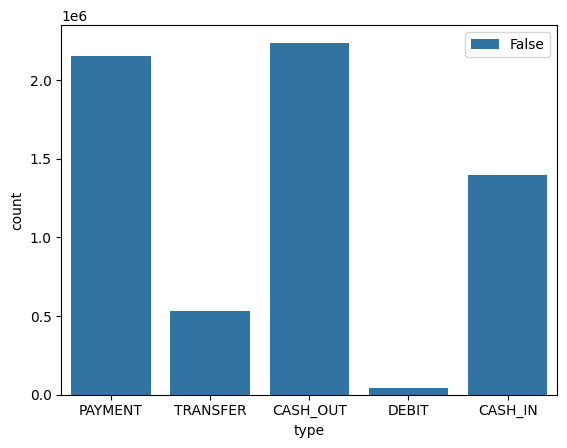

In [23]:
sns.countplot(x='type',hue='isFraud'==1,data=df)

Most fraud transactions occur in TRANSFER and CASH_OUT. PAYMENT, CASH_IN, and DEBIT contain no fraud cases in this dataset.

<Axes: xlabel='step', ylabel='count'>

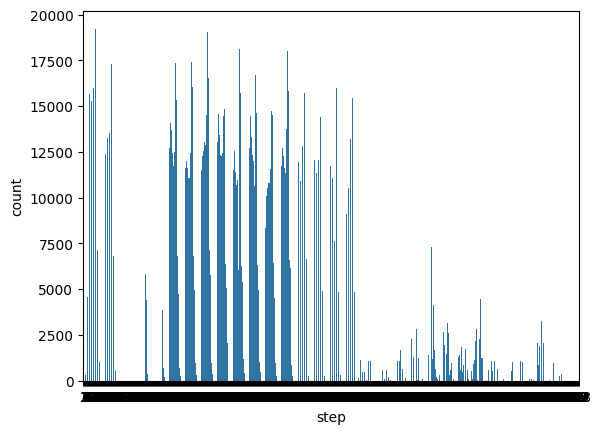

In [ ]:
sns.countplot(x='step',data=df)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2684404 entries, 0 to 6362618
Data columns (total 15 columns):
 #   Column                Dtype  
---  ------                -----  
 0   step                  int64  
 1   type                  object 
 2   amount                float64
 3   nameOrig              object 
 4   oldbalanceOrg         float64
 5   newbalanceOrig        float64
 6   nameDest              object 
 7   oldbalanceDest        float64
 8   newbalanceDest        float64
 9   isFraud               int64  
 10  isFlaggedFraud        int64  
 11  hour                  int64  
 12  midnight              int64  
 13  sender_balance_org    float64
 14  receiver_balance_org  float64
dtypes: float64(7), int64(5), object(3)
memory usage: 327.7+ MB


In [32]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,midnight,sender_balance_org,receiver_balance_org
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,1,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,1,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,1,181.00,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,1,11668.14,0.0
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0,1,1,7817.71,0.0


there are a lot of columns that are not required such as [step,nameorig,namedest,isflaggedfraud]

<Axes: xlabel='isFraud', ylabel='amount'>

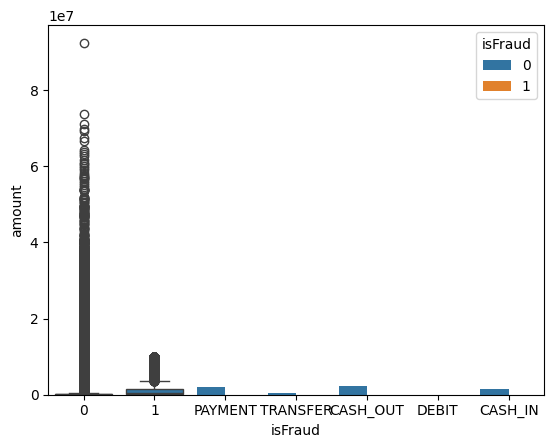

In [20]:
pd.crosstab(df['type'], df['isFraud'])
pd.crosstab(df['type'], df['isFraud'], normalize='index') * 100
df.groupby('isFraud')['amount'].describe()
df.groupby('hour')['isFraud'].mean().sort_values(ascending=False)
sns.boxplot(x='isFraud', y='amount', data=df)
sns.countplot(x='type', hue='isFraud', data=df)


EDA shows that the dataset is highly imbalanced, with far more legitimate transactions than fraudulent transactions. Fraud cases are mainly concentrated in TRANSFER and CASH_OUT transaction types. Transaction amount is useful, but fraud is not restricted to only very large amounts. Time-based features such as hour and midnight flag, along with balance-difference features, may help the model detect suspicious behavior.

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df['differnnce_in_ender_account']=df['oldbalanceOrg']-df['newbalanceOrig']

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,differnnce_in_ender_account
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14


In [11]:
df.head(20)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,differnnce_in_ender_account
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0,181.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0,11668.14
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0,7817.71
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0,7107.77
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0,7861.64
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0,2671.00
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0,5337.77


In [10]:
df['amount']==df['differnnce_in_ender_account']

0          False
1          False
2           True
3           True
4           True
           ...  
6362615     True
6362616     True
6362617     True
6362618     True
6362619     True
Length: 6362620, dtype: bool

In [8]:
df['amount'].mean()

np.float64(179861.90354913071)

In [7]:
df['differnnce_in_ender_account'].mean()

np.float64(-21230.564504102083)